1. Transaction data analysis 
Thinking process:
Step 1 : Data Preparation : Loaded the transaction data, filtered the 'PROCESS' transactions, along with numbering each user's transactions as 1st, 2nd, 3rd, etc.
Step 2 : Analyze Patterns : Calaculated the average time bectween each user's 1st and 2nd Transaction. Calculated retention rate by dividing the no. of users with 2nd transaction to no. of user's with 1st transaction. Calculate the average value of all transactions after 1st transaction.
Step 3 : Visualisation of results.

In [103]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [104]:
def load_transaction_data(file_path):
    try:
        df = pd.read_csv(file_path)
        print(f"Data loaded successfully. Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print("File not found. Please check the file path.")
        return None
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

In [105]:
def preprocess_data(df):
    df['created_at'] = pd.to_datetime(df['created_at'])
    
    df_success = df[df['payment_status'] == 'PROCESSED'].copy()
    
    df_success = df_success.sort_values(['adv_id', 'created_at'])
    
    df_success['transaction_sequence'] = df_success.groupby('adv_id').cumcount() + 1
    
    print(f"Successful transactions: {len(df_success)}")
    print(f"Total users: {df_success['adv_id'].nunique()}")
    
    return df_success

In [106]:
def analyze_transaction_patterns(df):
    print("Average time to second transaction")
    
    first_txns = df[df['transaction_sequence'] == 1].copy()
    second_txns = df[df['transaction_sequence'] == 2].copy()
    
    time_to_second = first_txns.merge(
        second_txns[['adv_id', 'created_at']], 
        on='adv_id', 
        suffixes=('_first', '_second')
    )
    
    time_to_second['time_diff_hours'] = (
        time_to_second['created_at_second'] - time_to_second['created_at_first']
    ).dt.total_seconds() / 3600
    
    time_to_second['time_diff_days'] = time_to_second['time_diff_hours'] / 24
    
    avg_time_hours = time_to_second['time_diff_hours'].mean()
    avg_time_days = time_to_second['time_diff_days'].mean()
    median_time_hours = time_to_second['time_diff_hours'].median()
    median_time_days = time_to_second['time_diff_days'].median()
    
    print(f"Average time to second transaction: {avg_time_hours:.2f} hours ({avg_time_days:.2f} days)")
    print(f"Median time to second transaction: {median_time_hours:.2f} hours ({median_time_days:.2f} days)")
    print(f"Users who made a second transaction: {len(time_to_second)}")
    
    print("Percentage of users with second transaction")
    
    total_users_with_first_txn = len(first_txns)
    users_with_second_txn = len(second_txns)
    
    if total_users_with_first_txn == 0:
        retention_rate = 0
        print("No users with a first transaction found. Cannot calculate retention rate.")
    else:
        retention_rate = (users_with_second_txn / total_users_with_first_txn) * 100
    
    print(f"Total users with first transaction: {total_users_with_first_txn}")
    print(f"Users with second transaction: {users_with_second_txn}")
    print(f"Retention rate (second transaction): {retention_rate:.2f}%")
    
    print("Average transaction amount after first transaction")
  
    
    subsequent_txns = df[df['transaction_sequence'] > 1].copy()
    
    avg_subsequent_per_user = subsequent_txns.groupby('adv_id')['value_in_paise'].mean()
    
    overall_avg_subsequent = subsequent_txns['value_in_paise'].mean()
    
    avg_of_user_averages = avg_subsequent_per_user.mean()
    
    print(f"Overall average of all subsequent transactions: {overall_avg_subsequent:.2f} paise")
    print(f"Average of user-level averages: {avg_of_user_averages:.2f} paise")
    print(f"Total subsequent transactions: {len(subsequent_txns)}")
    print(f"Users with subsequent transactions: {len(avg_subsequent_per_user)}")
    
    print("ADDITIONAL INSIGHTS")
   
    
    sequence_dist = df['transaction_sequence'].value_counts().sort_index()
    print(f"\nTransaction sequence distribution:")
    for seq, count in sequence_dist.head(10).items():
        print(f"  Transaction {seq}: {count} users")
    
    first_txn_stats = first_txns['value_in_paise'].describe()
    print(f"\nFirst transaction amount statistics:")
    print(f"  Mean: {first_txn_stats['mean']:.2f} paise")
    print(f"  Median: {first_txn_stats['50%']:.2f} paise")
    print(f"  Std: {first_txn_stats['std']:.2f} paise")
    
    return {
        'time_to_second': time_to_second,
        'retention_rate': retention_rate,
        'avg_subsequent_amount': avg_of_user_averages,
        'first_txns': first_txns,
        'subsequent_txns': subsequent_txns
    }

In [107]:
def create_visualizations(results):
    
    plt.figure(figsize=(15, 12))
    plt.suptitle("Transaction Analysis Visualizations", fontsize=16)

    time_to_second = results.get('time_to_second', pd.DataFrame())
    first_txns = results.get('first_txns', pd.DataFrame())
    subsequent_txns = results.get('subsequent_txns', pd.DataFrame())
    
    plt.subplot(2, 3, 1)
    if not time_to_second.empty:
        time_to_second_capped = time_to_second[time_to_second['time_diff_days'] <= 30]
        plt.hist(time_to_second_capped['time_diff_days'], bins=30, alpha=0.7, color='skyblue')
        plt.axvline(time_to_second['time_diff_days'].mean(), color='red', linestyle='--',  
                    label=f'Mean: {time_to_second["time_diff_days"].mean():.2f} days')
        plt.legend()
    else:
        plt.text(0.5, 0.5, 'No second transactions found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
    plt.xlabel('Days to Second Transaction')
    plt.ylabel('Number of Users')
    plt.title('Time to Second Transaction')

    plt.subplot(2, 3, 2)
    if not subsequent_txns.empty:
        sequence_dist = subsequent_txns['transaction_sequence'].value_counts().sort_index()
        sequence_dist.head(10).plot(kind='bar', color='lightgreen')
        plt.xticks(rotation=45)
    else:
        plt.text(0.5, 0.5, 'No subsequent transactions found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
    plt.xlabel('Transaction Sequence')
    plt.ylabel('Number of Transactions')
    plt.title('Transaction Sequence Distribution')

    plt.subplot(2, 3, 3)
    plot_data = []
    plot_labels = []
    if not first_txns.empty:
        plot_data.append(first_txns['value_in_paise'])
        plot_labels.append('First')
    if not subsequent_txns.empty:
        plot_data.append(subsequent_txns['value_in_paise'])
        plot_labels.append('Subsequent')
        
    if plot_data:
        plt.boxplot(plot_data, labels=plot_labels)
        plt.yscale('log')
    else:
        plt.text(0.5, 0.5, 'No transactions to compare', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
    plt.ylabel('Transaction Amount (paise)')
    plt.title('First vs Subsequent Amounts')
    
    plt.subplot(2, 3, 4)
    if not first_txns.empty:
        first_count = len(first_txns)
        sequence_counts = subsequent_txns['transaction_sequence'].value_counts().sort_index()
        funnel_data = [first_count] + sequence_counts.head(9).tolist()
        funnel_labels = ['1st'] + [f'{i}nd' if i==2 else f'{i}rd' if i==3 else f'{i}th' for i in range(2, len(funnel_data) + 1)]
        plt.plot(funnel_labels, funnel_data, marker='o', linewidth=2, markersize=8)
        plt.xticks(rotation=45)
    else:
        plt.text(0.5, 0.5, 'No first transactions found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
    plt.xlabel('Transaction Sequence')
    plt.ylabel('Number of Users')
    plt.title('User Retention Funnel')

    plt.subplot(2, 3, 5)
    if not first_txns.empty:
        payment_methods = first_txns['payment_method'].value_counts().head(8)
        if not payment_methods.empty:
            plt.pie(payment_methods.values, labels=payment_methods.index, autopct='%1.1f%%', startangle=90)
        else:
            plt.text(0.5, 0.5, 'No payment methods found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
    else:
        plt.text(0.5, 0.5, 'No first transactions found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
    plt.title('Payment Methods (First Txns)')
    
    plt.subplot(2, 3, 6)
    plotted = False
    if not first_txns.empty:
        plt.hist(first_txns['value_in_paise'], bins=50, alpha=0.7, color='orange', label='First')
        plotted = True
    if not subsequent_txns.empty:
        plt.hist(subsequent_txns['value_in_paise'], bins=50, alpha=0.7, color='purple', label='Subsequent')
        plotted = True
        
    if plotted:
        plt.legend()
        plt.yscale('log')
    else:
        plt.text(0.5, 0.5, 'No transaction data', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
    plt.xlabel('Transaction Amount (paise)')
    plt.ylabel('Frequency')
    plt.title('Transaction Amount Distribution')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    plt.show()

In [108]:
def generate_summary_report(results):
    
   time_to_second = results['time_to_second']
   retention_rate = results['retention_rate']
   avg_subsequent_amount = results['avg_subsequent_amount']
   first_txns = results['first_txns']
   subsequent_txns = results['subsequent_txns']
    
   print(f"""
   1. AVERAGE TIME TO SECOND TRANSACTION: {time_to_second['time_diff_days'].mean():.2f} days
      - Median time: {time_to_second['time_diff_days'].median():.2f} days
      
   2. RETENTION RATE: {retention_rate:.2f}%
      - {retention_rate:.2f}% of users who made a first transaction also made a second transaction
      
   3. AVERAGE SUBSEQUENT TRANSACTION AMOUNT: {avg_subsequent_amount:.2f} paise
      - Total subsequent transactions analyzed: {len(subsequent_txns)}

   """)

In [109]:
def main():
    
    file_path = "1_txn_data.csv"
    
    df = load_transaction_data(file_path)
    if df is None:
        print("Cannot proceed without data. Please check the file path.")
        return
    
    print(f"Unique values found: {df['payment_status'].unique()}")
    
    df_processed = preprocess_data(df)
    
    results = analyze_transaction_patterns(df_processed)
    
    create_visualizations(results)
    
    generate_summary_report(results)
    

In [110]:
def analyze_user_segments(df):
    
    user_stats = df.groupby('adv_id').agg({
        'value_in_paise': ['count', 'sum', 'mean', 'std'],
        'created_at': ['min', 'max']
    }).reset_index()
    
    user_stats.columns = ['adv_id', 'txn_count', 'total_amount', 'avg_amount', 'std_amount', 'first_txn', 'last_txn']
    user_stats['days_active'] = (user_stats['last_txn'] - user_stats['first_txn']).dt.days
    
    user_stats['segment'] = pd.cut(user_stats['txn_count'], 
                                   bins=[0, 1, 3, 10, float('inf')], 
                                   labels=['One-time', 'Low-frequency', 'Medium-frequency', 'High-frequency'])
    
    return user_stats

In [111]:
def fraud_indicators(df):
    
    fraud_flags = []
    
    Q1 = df['value_in_paise'].quantile(0.25)
    Q3 = df['value_in_paise'].quantile(0.75)
    IQR = Q3 - Q1
    outlier_threshold = Q3 + 1.5 * IQR
    
    outliers = df[df['value_in_paise'] > outlier_threshold]
    
    df['time_diff'] = df.groupby('adv_id')['created_at'].diff()
    rapid_txns = df[df['time_diff'] < timedelta(minutes=1)]
    
    return {
        'amount_outliers': len(outliers),
        'rapid_transactions': len(rapid_txns),
        'outlier_threshold': outlier_threshold
    }

Data loaded successfully. Shape: (65936, 13)
Unique values found: ['PROCESSED' 'FAILED' 'PROCESSING']
Successful transactions: 55381
Total users: 26824
Average time to second transaction
Average time to second transaction: 39.35 hours (1.64 days)
Median time to second transaction: 26.66 hours (1.11 days)
Users who made a second transaction: 6417
Percentage of users with second transaction
Total users with first transaction: 26824
Users with second transaction: 6417
Retention rate (second transaction): 23.92%
Average transaction amount after first transaction
Overall average of all subsequent transactions: 5217.67 paise
Average of user-level averages: 3194.74 paise
Total subsequent transactions: 28540
Users with subsequent transactions: 6417
ADDITIONAL INSIGHTS

Transaction sequence distribution:
  Transaction 1.0: 26824 users
  Transaction 2.0: 6417 users
  Transaction 3.0: 2676 users
  Transaction 4.0: 1323 users
  Transaction 5.0: 810 users
  Transaction 6.0: 590 users
  Transaction 

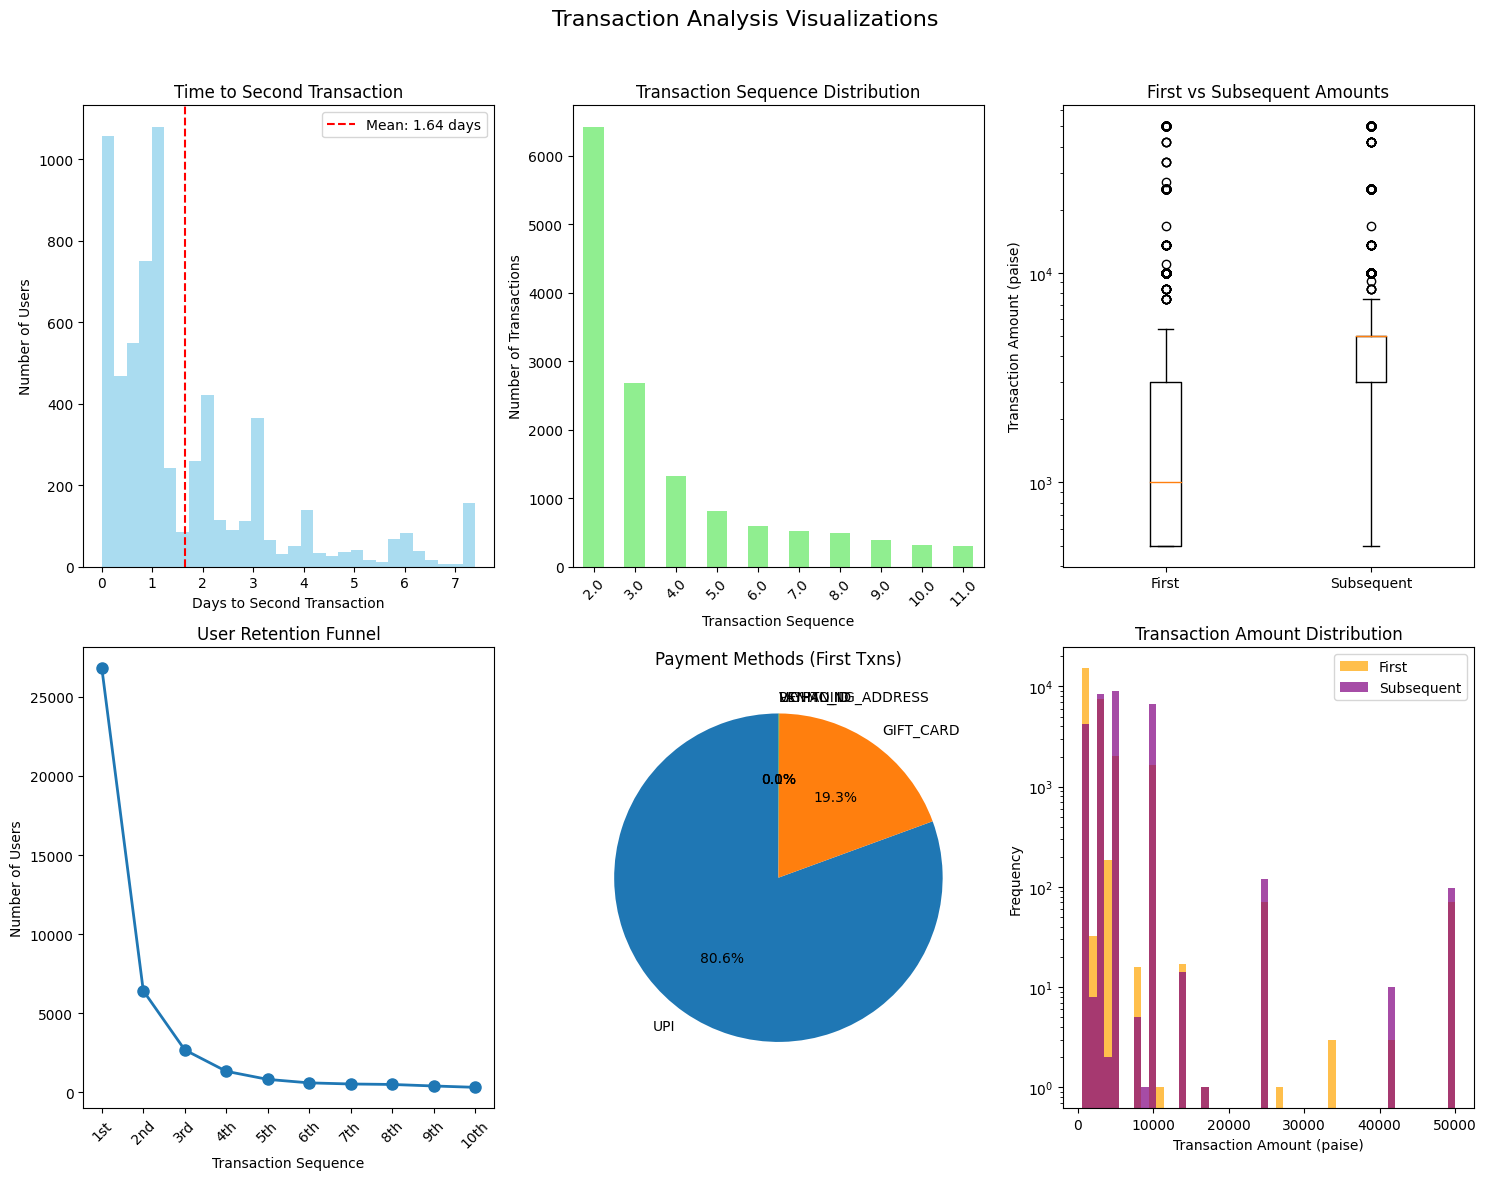


   1. AVERAGE TIME TO SECOND TRANSACTION: 1.64 days
      - Median time: 1.11 days
      
   2. RETENTION RATE: 23.92%
      - 23.92% of users who made a first transaction also made a second transaction
      
   3. AVERAGE SUBSEQUENT TRANSACTION AMOUNT: 3194.74 paise
      - Total subsequent transactions analyzed: 28540

   


In [112]:
if __name__ == "__main__":
    main()